# TFrecord文件

In [1]:
# 数据类别
voc_classes = {
    'none': 0,
    'aeroplane': 1,
    'bicycle': 2,
    'bird': 3,
    'boat': 4, 
    'bottle': 5,
    'bus': 6,
    'car': 7, 
    'cat': 8, 
    'chair': 9, 
    'cow': 10, 
    'diningtable': 11, 
    'dog': 12,
    'horse': 13, 
    'motorbike': 14,
    'person': 15, 
    'pottedplant': 16,
    'sheep': 17,
    'sofa': 18,
    'train': 19,
    'tvmonitor': 20,
}

## 读取VOC标注信息

In [2]:
# 读取XML
import xml.dom.minidom as xdom

In [3]:
# 定义方法:xml文件
def Parse_single_xml(xml_path):
    DOMTree = xdom.parse(xml_path)
    RootNode = DOMTree.documentElement
    # 对应的图像数据
    image_name = RootNode.getElementsByTagName("filename")[0].childNodes[0].data
    # 图像的宽高
    size = RootNode.getElementsByTagName('size')
    image_height = int(size[0].getElementsByTagName('height')[0].childNodes[0].data)
    image_width = int(size[0].getElementsByTagName('width')[0].childNodes[0].data)
    # 标注信息
    all_obj = RootNode.getElementsByTagName('object')
    bbox_label_list = []
    # 遍历所有的目标
    for obj in all_obj:
        # 类别名称
        label_name = obj.getElementsByTagName('name')[0].childNodes[0].data
        # 类别索引
        label_idx = voc_classes[label_name]
        # 框的信息
        bndbox = obj.getElementsByTagName('bndbox')
        # 获取坐标:左上角和右下角
        xmin = int(bndbox[0].getElementsByTagName('xmin')[0].childNodes[0].data)
        ymin = int(bndbox[0].getElementsByTagName('ymin')[0].childNodes[0].data)
        xmax = int(bndbox[0].getElementsByTagName('xmax')[0].childNodes[0].data)
        ymax = int(bndbox[0].getElementsByTagName('ymax')[0].childNodes[0].data)
        bbox_label_list.append([xmin,ymin,xmax,ymax,label_idx])
    return image_name,image_width,image_height,bbox_label_list

In [4]:
Parse_single_xml('VOCdevkit/VOC2007/Annotations/000005.xml')

('000005.jpg',
 500,
 375,
 [[263, 211, 324, 339, 9],
  [165, 264, 253, 372, 9],
  [5, 244, 67, 374, 9],
  [241, 194, 295, 299, 9],
  [277, 186, 312, 220, 9]])

## 写入数据到tfrecord中

In [4]:
import tensorflow as tf
import glob
import os

In [6]:
# 定义方法:将数据写入TFRecord文件中
def write_to_tfrecord(all_xml,tfrecord_file,img_path):
    # 1.实例化writer
    writer = tf.io.TFRecordWriter(tfrecord_file)
    # 2.获取要写入的数据:图像,标注信息,size
    for i,single_xml in enumerate(all_xml):
        # 读取xml
        img_name,image_width,image_height,bbox_label_list = Parse_single_xml(single_xml)
        # 获取图像的位置
        img_file = os.path.join(img_path,img_name)
        # 读取图像
        image_data= open(img_file,'rb').read()
        # 标注信息
        xmin =[]
        ymin=[]
        xmax =[]
        ymax=[]
        label=[]
        for j in range(len(bbox_label_list)):
            xmin.append(bbox_label_list[j][0])
            ymin.append(bbox_label_list[j][1])
            xmax.append(bbox_label_list[j][2])
            ymax.append(bbox_label_list[j][3])
            label.append(bbox_label_list[j][4])
        # 3.类型转换,并创建feature
        feature = {
            'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_data])),
            'width': tf.train.Feature(float_list=tf.train.FloatList(value=[image_width])),
            'height': tf.train.Feature(float_list=tf.train.FloatList(value=[image_height])),
            'xmin': tf.train.Feature(float_list=tf.train.FloatList(value=xmin)),
            'ymin': tf.train.Feature(float_list=tf.train.FloatList(value=ymin)),
            'xmax': tf.train.Feature(float_list=tf.train.FloatList(value=xmax)),
            'ymax': tf.train.Feature(float_list=tf.train.FloatList(value=ymax)),
            'label': tf.train.Feature(int64_list=tf.train.Int64List(value=label))
        }
        # 4.example创建
        example = tf.train.Example(features=tf.train.Features(feature = feature))
        # 5.序列化后写入到文件中
        writer.write(example.SerializeToString())
        print("第{}张图片写入完毕".format(i))
    # 6.关闭文件
    writer.close()

In [7]:
# 获取所有的xml文件
all_xml_path = glob.glob('VOCdevkit/VOC2007/Annotations/*.xml')
# 指定tfrecords文件的路径
tfrecord_path = 'voc_2007.tfrecords'
# 指定图像所在的路径
voc_img_path = 'VOCdevkit/VOC2007/JPEGImages'
# 写入数据
write_to_tfrecord(all_xml_path,tfrecord_path,voc_img_path)

第0张图片写入完毕
第1张图片写入完毕
第2张图片写入完毕
第3张图片写入完毕
第4张图片写入完毕
第5张图片写入完毕
第6张图片写入完毕
第7张图片写入完毕
第8张图片写入完毕
第9张图片写入完毕
第10张图片写入完毕
第11张图片写入完毕
第12张图片写入完毕
第13张图片写入完毕
第14张图片写入完毕
第15张图片写入完毕
第16张图片写入完毕
第17张图片写入完毕
第18张图片写入完毕
第19张图片写入完毕
第20张图片写入完毕
第21张图片写入完毕
第22张图片写入完毕
第23张图片写入完毕
第24张图片写入完毕
第25张图片写入完毕
第26张图片写入完毕
第27张图片写入完毕
第28张图片写入完毕
第29张图片写入完毕
第30张图片写入完毕
第31张图片写入完毕
第32张图片写入完毕
第33张图片写入完毕
第34张图片写入完毕
第35张图片写入完毕
第36张图片写入完毕
第37张图片写入完毕
第38张图片写入完毕
第39张图片写入完毕
第40张图片写入完毕
第41张图片写入完毕
第42张图片写入完毕
第43张图片写入完毕
第44张图片写入完毕
第45张图片写入完毕
第46张图片写入完毕
第47张图片写入完毕
第48张图片写入完毕
第49张图片写入完毕
第50张图片写入完毕
第51张图片写入完毕
第52张图片写入完毕
第53张图片写入完毕
第54张图片写入完毕
第55张图片写入完毕
第56张图片写入完毕
第57张图片写入完毕
第58张图片写入完毕
第59张图片写入完毕
第60张图片写入完毕
第61张图片写入完毕
第62张图片写入完毕
第63张图片写入完毕
第64张图片写入完毕
第65张图片写入完毕
第66张图片写入完毕
第67张图片写入完毕
第68张图片写入完毕
第69张图片写入完毕
第70张图片写入完毕
第71张图片写入完毕
第72张图片写入完毕
第73张图片写入完毕
第74张图片写入完毕
第75张图片写入完毕
第76张图片写入完毕
第77张图片写入完毕
第78张图片写入完毕
第79张图片写入完毕
第80张图片写入完毕
第81张图片写入完毕
第82张图片写入完毕
第83张图片写入完毕
第84张图片写入完毕
第85张图片写入完毕
第86张图片写入完毕
第87张图片写入完毕
第88张图片写入完毕
第89张图片写入完毕
第90张图片写入完毕
第91张图片写入完

第754张图片写入完毕
第755张图片写入完毕
第756张图片写入完毕
第757张图片写入完毕
第758张图片写入完毕
第759张图片写入完毕
第760张图片写入完毕
第761张图片写入完毕
第762张图片写入完毕
第763张图片写入完毕
第764张图片写入完毕
第765张图片写入完毕
第766张图片写入完毕
第767张图片写入完毕
第768张图片写入完毕
第769张图片写入完毕
第770张图片写入完毕
第771张图片写入完毕
第772张图片写入完毕
第773张图片写入完毕
第774张图片写入完毕
第775张图片写入完毕
第776张图片写入完毕
第777张图片写入完毕
第778张图片写入完毕
第779张图片写入完毕
第780张图片写入完毕
第781张图片写入完毕
第782张图片写入完毕
第783张图片写入完毕
第784张图片写入完毕
第785张图片写入完毕
第786张图片写入完毕
第787张图片写入完毕
第788张图片写入完毕
第789张图片写入完毕
第790张图片写入完毕
第791张图片写入完毕
第792张图片写入完毕
第793张图片写入完毕
第794张图片写入完毕
第795张图片写入完毕
第796张图片写入完毕
第797张图片写入完毕
第798张图片写入完毕
第799张图片写入完毕
第800张图片写入完毕
第801张图片写入完毕
第802张图片写入完毕
第803张图片写入完毕
第804张图片写入完毕
第805张图片写入完毕
第806张图片写入完毕
第807张图片写入完毕
第808张图片写入完毕
第809张图片写入完毕
第810张图片写入完毕
第811张图片写入完毕
第812张图片写入完毕
第813张图片写入完毕
第814张图片写入完毕
第815张图片写入完毕
第816张图片写入完毕
第817张图片写入完毕
第818张图片写入完毕
第819张图片写入完毕
第820张图片写入完毕
第821张图片写入完毕
第822张图片写入完毕
第823张图片写入完毕
第824张图片写入完毕
第825张图片写入完毕
第826张图片写入完毕
第827张图片写入完毕
第828张图片写入完毕
第829张图片写入完毕
第830张图片写入完毕
第831张图片写入完毕
第832张图片写入完毕
第833张图片写入完毕
第834张图片写入完毕
第835张图片写入完毕
第836张图片写入完毕
第837

第1477张图片写入完毕
第1478张图片写入完毕
第1479张图片写入完毕
第1480张图片写入完毕
第1481张图片写入完毕
第1482张图片写入完毕
第1483张图片写入完毕
第1484张图片写入完毕
第1485张图片写入完毕
第1486张图片写入完毕
第1487张图片写入完毕
第1488张图片写入完毕
第1489张图片写入完毕
第1490张图片写入完毕
第1491张图片写入完毕
第1492张图片写入完毕
第1493张图片写入完毕
第1494张图片写入完毕
第1495张图片写入完毕
第1496张图片写入完毕
第1497张图片写入完毕
第1498张图片写入完毕
第1499张图片写入完毕
第1500张图片写入完毕
第1501张图片写入完毕
第1502张图片写入完毕
第1503张图片写入完毕
第1504张图片写入完毕
第1505张图片写入完毕
第1506张图片写入完毕
第1507张图片写入完毕
第1508张图片写入完毕
第1509张图片写入完毕
第1510张图片写入完毕
第1511张图片写入完毕
第1512张图片写入完毕
第1513张图片写入完毕
第1514张图片写入完毕
第1515张图片写入完毕
第1516张图片写入完毕
第1517张图片写入完毕
第1518张图片写入完毕
第1519张图片写入完毕
第1520张图片写入完毕
第1521张图片写入完毕
第1522张图片写入完毕
第1523张图片写入完毕
第1524张图片写入完毕
第1525张图片写入完毕
第1526张图片写入完毕
第1527张图片写入完毕
第1528张图片写入完毕
第1529张图片写入完毕
第1530张图片写入完毕
第1531张图片写入完毕
第1532张图片写入完毕
第1533张图片写入完毕
第1534张图片写入完毕
第1535张图片写入完毕
第1536张图片写入完毕
第1537张图片写入完毕
第1538张图片写入完毕
第1539张图片写入完毕
第1540张图片写入完毕
第1541张图片写入完毕
第1542张图片写入完毕
第1543张图片写入完毕
第1544张图片写入完毕
第1545张图片写入完毕
第1546张图片写入完毕
第1547张图片写入完毕
第1548张图片写入完毕
第1549张图片写入完毕
第1550张图片写入完毕
第1551张图片写入完毕
第1552张图片写入完毕
第1553张图片写入完毕

第2146张图片写入完毕
第2147张图片写入完毕
第2148张图片写入完毕
第2149张图片写入完毕
第2150张图片写入完毕
第2151张图片写入完毕
第2152张图片写入完毕
第2153张图片写入完毕
第2154张图片写入完毕
第2155张图片写入完毕
第2156张图片写入完毕
第2157张图片写入完毕
第2158张图片写入完毕
第2159张图片写入完毕
第2160张图片写入完毕
第2161张图片写入完毕
第2162张图片写入完毕
第2163张图片写入完毕
第2164张图片写入完毕
第2165张图片写入完毕
第2166张图片写入完毕
第2167张图片写入完毕
第2168张图片写入完毕
第2169张图片写入完毕
第2170张图片写入完毕
第2171张图片写入完毕
第2172张图片写入完毕
第2173张图片写入完毕
第2174张图片写入完毕
第2175张图片写入完毕
第2176张图片写入完毕
第2177张图片写入完毕
第2178张图片写入完毕
第2179张图片写入完毕
第2180张图片写入完毕
第2181张图片写入完毕
第2182张图片写入完毕
第2183张图片写入完毕
第2184张图片写入完毕
第2185张图片写入完毕
第2186张图片写入完毕
第2187张图片写入完毕
第2188张图片写入完毕
第2189张图片写入完毕
第2190张图片写入完毕
第2191张图片写入完毕
第2192张图片写入完毕
第2193张图片写入完毕
第2194张图片写入完毕
第2195张图片写入完毕
第2196张图片写入完毕
第2197张图片写入完毕
第2198张图片写入完毕
第2199张图片写入完毕
第2200张图片写入完毕
第2201张图片写入完毕
第2202张图片写入完毕
第2203张图片写入完毕
第2204张图片写入完毕
第2205张图片写入完毕
第2206张图片写入完毕
第2207张图片写入完毕
第2208张图片写入完毕
第2209张图片写入完毕
第2210张图片写入完毕
第2211张图片写入完毕
第2212张图片写入完毕
第2213张图片写入完毕
第2214张图片写入完毕
第2215张图片写入完毕
第2216张图片写入完毕
第2217张图片写入完毕
第2218张图片写入完毕
第2219张图片写入完毕
第2220张图片写入完毕
第2221张图片写入完毕
第2222张图片写入完毕

第2810张图片写入完毕
第2811张图片写入完毕
第2812张图片写入完毕
第2813张图片写入完毕
第2814张图片写入完毕
第2815张图片写入完毕
第2816张图片写入完毕
第2817张图片写入完毕
第2818张图片写入完毕
第2819张图片写入完毕
第2820张图片写入完毕
第2821张图片写入完毕
第2822张图片写入完毕
第2823张图片写入完毕
第2824张图片写入完毕
第2825张图片写入完毕
第2826张图片写入完毕
第2827张图片写入完毕
第2828张图片写入完毕
第2829张图片写入完毕
第2830张图片写入完毕
第2831张图片写入完毕
第2832张图片写入完毕
第2833张图片写入完毕
第2834张图片写入完毕
第2835张图片写入完毕
第2836张图片写入完毕
第2837张图片写入完毕
第2838张图片写入完毕
第2839张图片写入完毕
第2840张图片写入完毕
第2841张图片写入完毕
第2842张图片写入完毕
第2843张图片写入完毕
第2844张图片写入完毕
第2845张图片写入完毕
第2846张图片写入完毕
第2847张图片写入完毕
第2848张图片写入完毕
第2849张图片写入完毕
第2850张图片写入完毕
第2851张图片写入完毕
第2852张图片写入完毕
第2853张图片写入完毕
第2854张图片写入完毕
第2855张图片写入完毕
第2856张图片写入完毕
第2857张图片写入完毕
第2858张图片写入完毕
第2859张图片写入完毕
第2860张图片写入完毕
第2861张图片写入完毕
第2862张图片写入完毕
第2863张图片写入完毕
第2864张图片写入完毕
第2865张图片写入完毕
第2866张图片写入完毕
第2867张图片写入完毕
第2868张图片写入完毕
第2869张图片写入完毕
第2870张图片写入完毕
第2871张图片写入完毕
第2872张图片写入完毕
第2873张图片写入完毕
第2874张图片写入完毕
第2875张图片写入完毕
第2876张图片写入完毕
第2877张图片写入完毕
第2878张图片写入完毕
第2879张图片写入完毕
第2880张图片写入完毕
第2881张图片写入完毕
第2882张图片写入完毕
第2883张图片写入完毕
第2884张图片写入完毕
第2885张图片写入完毕
第2886张图片写入完毕

第3539张图片写入完毕
第3540张图片写入完毕
第3541张图片写入完毕
第3542张图片写入完毕
第3543张图片写入完毕
第3544张图片写入完毕
第3545张图片写入完毕
第3546张图片写入完毕
第3547张图片写入完毕
第3548张图片写入完毕
第3549张图片写入完毕
第3550张图片写入完毕
第3551张图片写入完毕
第3552张图片写入完毕
第3553张图片写入完毕
第3554张图片写入完毕
第3555张图片写入完毕
第3556张图片写入完毕
第3557张图片写入完毕
第3558张图片写入完毕
第3559张图片写入完毕
第3560张图片写入完毕
第3561张图片写入完毕
第3562张图片写入完毕
第3563张图片写入完毕
第3564张图片写入完毕
第3565张图片写入完毕
第3566张图片写入完毕
第3567张图片写入完毕
第3568张图片写入完毕
第3569张图片写入完毕
第3570张图片写入完毕
第3571张图片写入完毕
第3572张图片写入完毕
第3573张图片写入完毕
第3574张图片写入完毕
第3575张图片写入完毕
第3576张图片写入完毕
第3577张图片写入完毕
第3578张图片写入完毕
第3579张图片写入完毕
第3580张图片写入完毕
第3581张图片写入完毕
第3582张图片写入完毕
第3583张图片写入完毕
第3584张图片写入完毕
第3585张图片写入完毕
第3586张图片写入完毕
第3587张图片写入完毕
第3588张图片写入完毕
第3589张图片写入完毕
第3590张图片写入完毕
第3591张图片写入完毕
第3592张图片写入完毕
第3593张图片写入完毕
第3594张图片写入完毕
第3595张图片写入完毕
第3596张图片写入完毕
第3597张图片写入完毕
第3598张图片写入完毕
第3599张图片写入完毕
第3600张图片写入完毕
第3601张图片写入完毕
第3602张图片写入完毕
第3603张图片写入完毕
第3604张图片写入完毕
第3605张图片写入完毕
第3606张图片写入完毕
第3607张图片写入完毕
第3608张图片写入完毕
第3609张图片写入完毕
第3610张图片写入完毕
第3611张图片写入完毕
第3612张图片写入完毕
第3613张图片写入完毕
第3614张图片写入完毕
第3615张图片写入完毕

第4196张图片写入完毕
第4197张图片写入完毕
第4198张图片写入完毕
第4199张图片写入完毕
第4200张图片写入完毕
第4201张图片写入完毕
第4202张图片写入完毕
第4203张图片写入完毕
第4204张图片写入完毕
第4205张图片写入完毕
第4206张图片写入完毕
第4207张图片写入完毕
第4208张图片写入完毕
第4209张图片写入完毕
第4210张图片写入完毕
第4211张图片写入完毕
第4212张图片写入完毕
第4213张图片写入完毕
第4214张图片写入完毕
第4215张图片写入完毕
第4216张图片写入完毕
第4217张图片写入完毕
第4218张图片写入完毕
第4219张图片写入完毕
第4220张图片写入完毕
第4221张图片写入完毕
第4222张图片写入完毕
第4223张图片写入完毕
第4224张图片写入完毕
第4225张图片写入完毕
第4226张图片写入完毕
第4227张图片写入完毕
第4228张图片写入完毕
第4229张图片写入完毕
第4230张图片写入完毕
第4231张图片写入完毕
第4232张图片写入完毕
第4233张图片写入完毕
第4234张图片写入完毕
第4235张图片写入完毕
第4236张图片写入完毕
第4237张图片写入完毕
第4238张图片写入完毕
第4239张图片写入完毕
第4240张图片写入完毕
第4241张图片写入完毕
第4242张图片写入完毕
第4243张图片写入完毕
第4244张图片写入完毕
第4245张图片写入完毕
第4246张图片写入完毕
第4247张图片写入完毕
第4248张图片写入完毕
第4249张图片写入完毕
第4250张图片写入完毕
第4251张图片写入完毕
第4252张图片写入完毕
第4253张图片写入完毕
第4254张图片写入完毕
第4255张图片写入完毕
第4256张图片写入完毕
第4257张图片写入完毕
第4258张图片写入完毕
第4259张图片写入完毕
第4260张图片写入完毕
第4261张图片写入完毕
第4262张图片写入完毕
第4263张图片写入完毕
第4264张图片写入完毕
第4265张图片写入完毕
第4266张图片写入完毕
第4267张图片写入完毕
第4268张图片写入完毕
第4269张图片写入完毕
第4270张图片写入完毕
第4271张图片写入完毕
第4272张图片写入完毕

第4889张图片写入完毕
第4890张图片写入完毕
第4891张图片写入完毕
第4892张图片写入完毕
第4893张图片写入完毕
第4894张图片写入完毕
第4895张图片写入完毕
第4896张图片写入完毕
第4897张图片写入完毕
第4898张图片写入完毕
第4899张图片写入完毕
第4900张图片写入完毕
第4901张图片写入完毕
第4902张图片写入完毕
第4903张图片写入完毕
第4904张图片写入完毕
第4905张图片写入完毕
第4906张图片写入完毕
第4907张图片写入完毕
第4908张图片写入完毕
第4909张图片写入完毕
第4910张图片写入完毕
第4911张图片写入完毕
第4912张图片写入完毕
第4913张图片写入完毕
第4914张图片写入完毕
第4915张图片写入完毕
第4916张图片写入完毕
第4917张图片写入完毕
第4918张图片写入完毕
第4919张图片写入完毕
第4920张图片写入完毕
第4921张图片写入完毕
第4922张图片写入完毕
第4923张图片写入完毕
第4924张图片写入完毕
第4925张图片写入完毕
第4926张图片写入完毕
第4927张图片写入完毕
第4928张图片写入完毕
第4929张图片写入完毕
第4930张图片写入完毕
第4931张图片写入完毕
第4932张图片写入完毕
第4933张图片写入完毕
第4934张图片写入完毕
第4935张图片写入完毕
第4936张图片写入完毕
第4937张图片写入完毕
第4938张图片写入完毕
第4939张图片写入完毕
第4940张图片写入完毕
第4941张图片写入完毕
第4942张图片写入完毕
第4943张图片写入完毕
第4944张图片写入完毕
第4945张图片写入完毕
第4946张图片写入完毕
第4947张图片写入完毕
第4948张图片写入完毕
第4949张图片写入完毕
第4950张图片写入完毕
第4951张图片写入完毕
第4952张图片写入完毕
第4953张图片写入完毕
第4954张图片写入完毕
第4955张图片写入完毕
第4956张图片写入完毕
第4957张图片写入完毕
第4958张图片写入完毕
第4959张图片写入完毕
第4960张图片写入完毕
第4961张图片写入完毕
第4962张图片写入完毕
第4963张图片写入完毕
第4964张图片写入完毕
第4965张图片写入完毕

## 读取tfrecord文件

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [5]:
# 1.获取到文件中的数据
raw_datasets = tf.data.TFRecordDataset("voc_2007.tfrecords")

In [6]:
# 2.定义特征的描述方法
feature_description={
    'image': tf.io.FixedLenFeature([], tf.string),
    'width': tf.io.FixedLenFeature([], tf.float32),
    'height': tf.io.FixedLenFeature([], tf.float32),
    'xmin': tf.io.VarLenFeature(tf.float32),
    'ymin': tf.io.VarLenFeature(tf.float32),
    'xmax': tf.io.VarLenFeature(tf.float32),
    'ymax': tf.io.VarLenFeature(tf.float32),
    'label': tf.io.VarLenFeature(tf.int64),
}

In [7]:
# 将数据解析回原始数据
def parse_example(example_string):
    # 将example转换为原始数据
    feature_dict = tf.io.parse_single_example(
        example_string, feature_description)
    # 图像数据
    image_data = tf.io.decode_jpeg(feature_dict['image'])
    # 坐标信息
    boxes = tf.stack([
        tf.sparse.to_dense(feature_dict['xmin']),
        tf.sparse.to_dense(feature_dict['ymin']),
        tf.sparse.to_dense(feature_dict['xmax']),
        tf.sparse.to_dense(feature_dict['ymax'])
    ],axis=1)
    # 类别信心
    label = tf.sparse.to_dense(feature_dict["label"])
    return image_data,feature_dict['width'],feature_dict['height'],boxes,label

In [8]:
# 使用map方法进行处理
raw_datasets = raw_datasets.map(parse_example)

tf.Tensor(
[[ 80. 217. 320. 273.]
 [197. 193. 257. 326.]
 [139. 184. 185. 231.]
 [258. 180. 312. 314.]
 [ 10. 195.  93. 358.]
 [ 82. 252. 243. 372.]
 [ 43. 319. 144. 375.]], shape=(7, 4), dtype=float32)
tf.Tensor(
[[ 80. 217. 320. 273.]
 [197. 193. 257. 326.]
 [139. 184. 185. 231.]
 [258. 180. 312. 314.]
 [ 10. 195.  93. 358.]
 [ 82. 252. 243. 372.]
 [ 43. 319. 144. 375.]], shape=(7, 4), dtype=float32)
tf.Tensor(
[[ 80. 217. 320. 273.]
 [197. 193. 257. 326.]
 [139. 184. 185. 231.]
 [258. 180. 312. 314.]
 [ 10. 195.  93. 358.]
 [ 82. 252. 243. 372.]
 [ 43. 319. 144. 375.]], shape=(7, 4), dtype=float32)
tf.Tensor(
[[ 80. 217. 320. 273.]
 [197. 193. 257. 326.]
 [139. 184. 185. 231.]
 [258. 180. 312. 314.]
 [ 10. 195.  93. 358.]
 [ 82. 252. 243. 372.]
 [ 43. 319. 144. 375.]], shape=(7, 4), dtype=float32)
tf.Tensor(
[[ 80. 217. 320. 273.]
 [197. 193. 257. 326.]
 [139. 184. 185. 231.]
 [258. 180. 312. 314.]
 [ 10. 195.  93. 358.]
 [ 82. 252. 243. 372.]
 [ 43. 319. 144. 375.]], shape=(7, 4), 

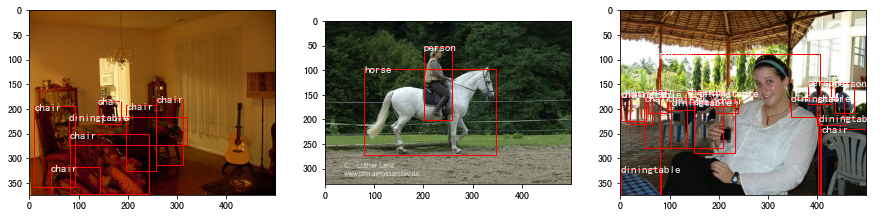

In [12]:
# 图像展示
# 将VOC_class字典的key和value进行翻转
new_voc_class = {v:k for k,v in voc_classes.items()}
# 画布
plt.figure(figsize=(15,10))
# 初始化
i=0
# 从raw_data_set中获取数据:image,size,box,label
for image,width,height,boxes,labels in raw_datasets.take(3):
    plt.subplot(1,3,i+1)
    # 绘制图像
    plt.imshow(image)
    # 绘制框和累呗
    ax = plt.gca()
    # 遍历所有的框
    for j in range(boxes.shape[0]):
        # 绘制框
        print(boxes)
        rect = Rectangle((boxes[j][0],boxes[j][1]),(boxes[j][2]-boxes[j][0]),boxes[j][3]-boxes[j][1],color='r',fill=False)
        ax.add_patch(rect)
        # 类别
        label_id = labels[j]
        # 类别信息
        labelimfo = new_voc_class.get(label_id.numpy())
        ax.text(boxes[j][0],boxes[j][1]+8,labelimfo,color='w',size=11,backgroundcolor="none")
    i+=1
# 图像显示
plt.show()

## 数据处理

In [14]:
def preprocess(image,bbox,input_shape=(416,416)):
    # 扩维
    image = tf.expand_dims(image,axis=0)
    # 获取图像的原始大大小
    img_shape = image.shape[1:3]
    # 对图像进行resize
    resize_image = tf.image.resize(image,input_shape,method=tf.image.ResizeMethod.BICUBIC,preserve_aspect_ratio=True)
    # 获取宽高
    resize_shape = resize_image.shape[1:3]
    # 获取填充的大小
    top_pad = (input_shape[0]-resize_shape[0])//2
    bottom_pad = input_shape[0]-resize_shape[0]-top_pad
    left_pad = (input_shape[1]-resize_shape[1])//2
    right_pad = input_shape[1]-resize_shape[1]-left_pad
    # 填充
    resize_image = tf.pad(resize_image,[[0,0],[top_pad,bottom_pad],[left_pad,right_pad],[0,0]],constant_values=128)
    # 类型转换
    image_data = tf.cast(resize_image,tf.float32)/255.
    # 对bbox进行调整
    # 尺度变换
    bbox = bbox*tf.convert_to_tensor([resize_shape[1],resize_shape[0],resize_shape[1],resize_shape[0]],dtype=tf.float32)
    bbox = bbox/tf.convert_to_tensor([img_shape[1],img_shape[0],img_shape[1],img_shape[0]],dtype=tf.float32)
    # 平移
    bbox = bbox+tf.convert_to_tensor([left_pad,top_pad,left_pad,top_pad],dtype=tf.float32)
    return image_data,bbox

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


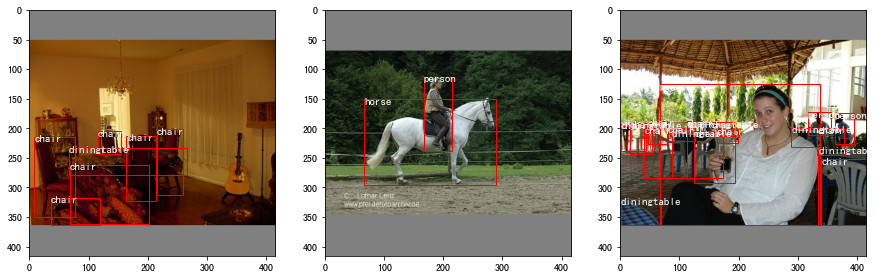

In [15]:
# 图像展示
# 将VOC_class字典的key和value进行翻转
new_voc_class = {v:k for k,v in voc_classes.items()}
# 画布
plt.figure(figsize=(15,10))
# 初始化
i=0
# 从raw_data_set中获取数据:image,size,box,label
for image,width,height,boxes,labels in raw_datasets.take(3):
    image,boxes = preprocess(image,boxes)
    plt.subplot(1,3,i+1)
    # 绘制图像
    plt.imshow(image[0])
    # 绘制框和累呗
    ax = plt.gca()
    # 遍历所有的框
    for j in range(boxes.shape[0]):
        # 绘制框
        rect = Rectangle((boxes[j][0],boxes[j][1]),(boxes[j][2]-boxes[j][0]),boxes[j][3]-boxes[j][1],color='r',fill=False)
        ax.add_patch(rect)
        # 类别
        label_id = labels[j]
        # 类别信息
        labelimfo = new_voc_class.get(label_id.numpy())
        ax.text(boxes[j][0],boxes[j][1]+8,labelimfo,color='w',size=11,backgroundcolor="none")
    i+=1
# 图像显示
plt.show()

# 模型搭建

In [16]:
import tensorflow.keras as keras
import tensorflow as tf

## CBL

In [17]:
def ConvBlock(input_shape,filters,kernel_size,strides=(1,1),padding = None):
    # 设置padding
    if strides ==(2,2):
        padding='valid'
    else:
        padding ='same'
    # 构建
    # 输入
    inputs = keras.Input(shape=input_shape)
    # 卷积层
    conv = keras.layers.Conv2D(filters,kernel_size,strides,padding,kernel_regularizer=keras.regularizers.L2(5e-4))(inputs)
    # BN层
    bn = keras.layers.BatchNormalization()(conv)
    # 激活
    output = keras.layers.LeakyReLU(alpha=0.1)(bn)
    return keras.Model(inputs,output)

In [18]:
cbl = ConvBlock((416,416,3),32,(3,3))

In [19]:
cbl.summary()

Model: "functional_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 416, 416, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 416, 416, 32)      896       
_________________________________________________________________
batch_normalization (BatchNo (None, 416, 416, 32)      128       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 416, 416, 32)      0         
Total params: 1,024
Trainable params: 960
Non-trainable params: 64
_________________________________________________________________


## ResX

In [20]:
def ResBlock(input_shape,filters,blocks):
    # 输入
    inputs = keras.Input(input_shape)
    # pad
    pad = keras.layers.ZeroPadding2D(padding=((1,0),(1,0)))(inputs)
    # CBL
    results = ConvBlock(pad.shape[1:],filters=filters,kernel_size=(3,3),strides=(2,2))(pad)
    # 构建残差单元
    for i in range(blocks):
        # CBL
        results_conv = ConvBlock(results.shape[1:],filters=filters//2,kernel_size=(1,1))(results)
        # CBL
        results_conv = ConvBlock(results_conv.shape[1:],filters=filters,kernel_size=(3,3))(results_conv)
        # add
        results = keras.layers.Add()([results_conv,results])
    return keras.Model(inputs,results)

In [21]:
res = ResBlock((416,416,3),32,2)

In [22]:
res.summary()

Model: "functional_13"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 416, 416, 3) 0                                            
__________________________________________________________________________________________________
zero_padding2d (ZeroPadding2D)  (None, 417, 417, 3)  0           input_2[0][0]                    
__________________________________________________________________________________________________
functional_3 (Functional)       (None, 208, 208, 32) 1024        zero_padding2d[0][0]             
__________________________________________________________________________________________________
functional_5 (Functional)       (None, 208, 208, 16) 592         functional_3[0][0]               
______________________________________________________________________________________

## Backbone

In [23]:
def Body(input_shape):
    # 输入
    inputs = keras.Input(input_shape)
    # CBL
    cb = ConvBlock(inputs.shape[1:],filters=32,kernel_size=(3,3))(inputs)
    # RES1
    rb1 = ResBlock(cb.shape[1:],filters=64,blocks=1)(cb)
    rb2 = ResBlock(rb1.shape[1:],filters=128,blocks=2)(rb1)
    rb3 = ResBlock(rb2.shape[1:],filters=256,blocks=8)(rb2)
    rb4 = ResBlock(rb3.shape[1:],filters=512,blocks=8)(rb3)
    rb5 = ResBlock(rb4.shape[1:],filters=1024,blocks=8)(rb4)
    return keras.Model(inputs,outputs = (rb5,rb4,rb3))

In [24]:
boby = Body((416,416,3))

In [25]:
boby.summary()

Model: "functional_145"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_8 (InputLayer)         [(None, 416, 416, 3)]     0         
_________________________________________________________________
functional_15 (Functional)   (None, 416, 416, 32)      1024      
_________________________________________________________________
functional_23 (Functional)   (None, 208, 208, 64)      39712     
_________________________________________________________________
functional_35 (Functional)   (None, 104, 104, 128)     240128    
_________________________________________________________________
functional_71 (Functional)   (None, 52, 52, 256)       2932992   
_________________________________________________________________
functional_107 (Functional)  (None, 26, 26, 512)       11698688  
_________________________________________________________________
functional_143 (Functional)  (None, 13, 13, 1024)   

## 输出部分

In [26]:
def Output(input_shape,input_filters,output_filters):
    # 输入
    inputs = keras.Input(input_shape)
    # 串联CBL
    cb1 = ConvBlock(inputs.shape[1:],filters=input_filters,kernel_size=(1,1))(inputs)
    cb2 = ConvBlock(cb1.shape[1:],filters=input_filters*2,kernel_size=(3,3))(cb1)
    cb3 = ConvBlock(cb2.shape[1:],filters=input_filters,kernel_size=(1,1))(cb2)
    cb4 = ConvBlock(cb3.shape[1:],filters=input_filters*2,kernel_size=(3,3))(cb3)
    cb5 = ConvBlock(cb4.shape[1:],filters=input_filters,kernel_size=(1,1))(cb4)
    cb6 = ConvBlock(cb5.shape[1:],filters=input_filters*2,kernel_size=(3,3))(cb5)
    cb7 = ConvBlock(cb6.shape[1:],filters=output_filters,kernel_size=(1,1))(cb6)
    return keras.Model(inputs,outputs = (cb5,cb7))

In [27]:
output = Output((13,13,1024),32,255)

In [28]:
output.summary()

Model: "functional_161"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_74 (InputLayer)        [(None, 13, 13, 1024)]    0         
_________________________________________________________________
functional_147 (Functional)  (None, 13, 13, 32)        32928     
_________________________________________________________________
functional_149 (Functional)  (None, 13, 13, 64)        18752     
_________________________________________________________________
functional_151 (Functional)  (None, 13, 13, 32)        2208      
_________________________________________________________________
functional_153 (Functional)  (None, 13, 13, 64)        18752     
_________________________________________________________________
functional_155 (Functional)  (None, 13, 13, 32)        2208      
_________________________________________________________________
functional_157 (Functional)  (None, 13, 13, 64)     

## V3

In [29]:
def YOLOv3(input_shape,classnum=80):
    # anchor数目
    anchor_num = 3
    # 输入数据
    inputs = keras.Input(shape=input_shape)
    # 通过backbone获取特征图
    large,middle,small =Body(inputs.shape[1:])(inputs)
    # 大目标
    x1,y1 = Output(large.shape[1:],512,anchor_num*(classnum+5))(large)
    # 输出
    y1 = keras.layers.Reshape((input_shape[0]//32,input_shape[1]//32,3,5+classnum))(y1)
    # 中等目标
    cb1 = ConvBlock(x1.shape[1:],256,kernel_size=(1,1))(x1)
    # 上采样
    us1 = keras.layers.UpSampling2D(2)(cb1)
    # 融合
    cat1 = keras.layers.Concatenate()([us1,middle])
    # 输出
    x2,y2 = Output(cat1.shape[1:],256,anchor_num*(classnum+5))(cat1)
    y2 = keras.layers.Reshape((input_shape[0]//16,input_shape[1]//16,3,5+classnum))(y2)
    # 小目标
    cb2 = ConvBlock(x2.shape[1:],128,kernel_size=(1,1))(x2)
    # 上采样
    us2 = keras.layers.UpSampling2D(2)(cb2)
    # 融合
    cat2 = keras.layers.Concatenate()([us2,small])
    # 输出
    x3,y3 = Output(cat2.shape[1:],128,anchor_num*(classnum+5))(cat2)
    y3 = keras.layers.Reshape((input_shape[0]//8,input_shape[1]//8,3,5+classnum))(y3)
    return keras.Model(inputs,outputs=(y1,y2,y3))

In [30]:
yolov3 = YOLOv3((416,416,3))

In [31]:
yolov3.summary()

Model: "functional_347"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_82 (InputLayer)           [(None, 416, 416, 3) 0                                            
__________________________________________________________________________________________________
functional_293 (Functional)     ((None, 13, 13, 1024 61640736    input_82[0][0]                   
__________________________________________________________________________________________________
functional_309 (Functional)     ((None, 13, 13, 512) 16014075    functional_293[0][0]             
__________________________________________________________________________________________________
functional_311 (Functional)     (None, 13, 13, 256)  132352      functional_309[0][0]             
_____________________________________________________________________________________

## 输出调整

In [32]:
def OutputParser(input_shape, img_shape, anchors):
    # 输入数据
    feats = tf.keras.Input(input_shape)
    # 对回归结果进行调整
    # 1.计算网格左上角坐标
    grid_y = tf.keras.layers.Lambda(lambda x: tf.tile(tf.reshape(tf.range(tf.cast(tf.shape(
        x)[1], dtype=tf.float32), dtype=tf.float32), (-1, 1, 1, 1)), (1, tf.shape(x)[2], 1, 1)))(feats)
    grid_x = tf.keras.layers.Lambda(lambda x: tf.tile(tf.reshape(tf.range(tf.cast(tf.shape(
        x)[2], dtype=tf.float32), dtype=tf.float32), (1, -1, 1, 1)), (tf.shape(x)[1], 1, 1, 1)))(feats)
    # 构建grid的网格表示
    grid = tf.keras.layers.Concatenate(axis=-1)([grid_x, grid_y])
    # 2.计算box_xy
    box_xy = tf.keras.layers.Lambda(lambda x: (tf.math.sigmoid(x[0][..., 0:2]) + x[1]) / tf.cast(
        [tf.shape(x[1])[1], tf.shape(x[1])[0]], dtype=tf.float32))([feats, grid])
    # 3.计算box_wh
    box_wh = tf.keras.layers.Lambda(lambda x, y, z: tf.math.exp(x[..., 2:4]) * y / tf.cast(
        [z[1], z[0]], dtype=tf.float32), arguments={'y': anchors, 'z': img_shape})(feats)
    # 4.是否包含目标的置信度
    box_confidence = tf.keras.layers.Lambda(
        lambda x: tf.math.sigmoid(x[..., 4]))(feats)
    # 5.分类
    box_class_probs = tf.keras.layers.Lambda(
        lambda x: tf.math.sigmoid(x[..., 5:]))(feats)
    # 返回结果
    return tf.keras.Model(inputs=feats, outputs=(box_xy, box_wh, box_confidence, box_class_probs))

# 模型训练


## 损失函数的计算

In [33]:
def Loss(img_shape, class_num=80):
    # 设置anchor
    anchors = {2: [[10, 13], [16, 30], [33, 23]], 1: [[30, 61], [
        62, 45], [59, 119]], 0: [[116, 90], [156, 198], [373, 326]]}
    # 设置Loss的输入
    input_shapes = [
        (img_shape[0] // 32, img_shape[1] // 32, 3, 5 + class_num),
        (img_shape[0] // 16, img_shape[1] // 16, 3, 5 + class_num),
        (img_shape[0] // 8, img_shape[1] // 8, 3, 5 + class_num)
    ]
    # 定义Loss的inputs:预测值和目标值
    inputs = [tf.keras.Input(input_shape) for input_shape in input_shapes]
    labels = [tf.keras.Input(input_shape) for input_shape in input_shapes]
    # 计算损失
    losses = list()
    # 遍历多个尺度
    for l in range(3):
        input_shape_of_this_layer = input_shapes[l]
        anchors_of_this_layer = anchors[l]
        input_of_this_layer = inputs[l]
        label_of_this_layer = labels[l]
        # 网络输出
        pred_xy, pred_wh, pred_box_confidence, pred_class = OutputParser(
            input_shape_of_this_layer, img_shape, anchors_of_this_layer)(input_of_this_layer)
        # 预测框
        pred_box = tf.keras.layers.Concatenate()([pred_xy, pred_wh])
        # 真实值
        true_box = tf.keras.layers.Lambda(
            lambda x: x[..., 0:4])(label_of_this_layer)
        true_box_confidence = tf.keras.layers.Lambda(
            lambda x: x[..., 4])(label_of_this_layer)
        true_class = tf.keras.layers.Lambda(
            lambda x: x[..., 5:])(label_of_this_layer)
        # 正负样本
        object_box = tf.keras.layers.Lambda(
            lambda x: tf.cast(x, dtype=tf.bool))(true_box_confidence)
        # 1.box:MSE,只有正样本参与损失计算
        pos_loss = tf.keras.layers.Lambda(lambda x: tf.math.reduce_sum(tf.keras.losses.MSE(
            tf.boolean_mask(x[0], x[2]), tf.boolean_mask(x[1], x[2]))))([true_box, pred_box, object_box])
        # 2.confidence:正负样本都要计算，二分类的交叉熵损失
        confidence_loss = tf.keras.layers.Lambda(lambda x: tf.keras.losses.BinaryCrossentropy(from_logits=False)(tf.boolean_mask(x[0], x[2]), tf.boolean_mask(x[1], x[2])) + 100 * tf.keras.losses.BinaryCrossentropy(
            from_logits=False)(tf.boolean_mask(x[0], tf.math.logical_not(x[2])), tf.boolean_mask(x[1], tf.math.logical_not(x[2]))))([true_box_confidence, pred_box_confidence, object_box])
        # 3.class:只有正样本计算损失 二分类的交叉熵损失
        class_loss = tf.keras.layers.Lambda(lambda x: tf.keras.losses.BinaryCrossentropy(from_logits=False)(
            tf.boolean_mask(x[0], x[2]), tf.boolean_mask(x[1], x[2])))([true_class, pred_class, object_box])
        # 4.总损失
        loss = tf.keras.layers.Lambda(lambda x: tf.math.add_n(x))(
            [pos_loss, confidence_loss, class_loss])
        losses.append(loss)
    loss = tf.keras.layers.Lambda(lambda x: tf.math.add_n(x))(losses)
    return tf.keras.Model(inputs=(*inputs, *labels), outputs=loss)

## 正负样本确定

In [61]:
# anchors
YOLOv3_anchors = np.array([[10, 13], [16, 30], [33, 23], [30, 61], [62, 45], [
                          59, 119], [116, 90], [156, 198], [373, 326]], dtype=np.int32)

In [66]:
def bbox_to_tensor(bbox, label, input_shape=(416, 416), anchors=YOLOv3_anchors, num_classes=80):

    # bbox.shape = (box num, 4) 真实值坐标表示为(xmin,ymin,xmax,ymax)，是相对坐标
    # label.shape = (box num) 每个标注框的类别
    # anchors = (9,2)
    # 获取有几个尺度的输出，每个尺度对应3个anchor:3
    num_layers = anchors.shape[0] // 3
    # anchor对应的特征图掩码：第一个特征图对应第6，7，8个anchor...
    anchor_mask = tf.cond(tf.equal(num_layers, 3), lambda: tf.constant(
        [[6, 7, 8], [3, 4, 5], [0, 1, 2]]), lambda: tf.constant([[3, 4, 5], [1, 2, 3]]))

    # bbox的相对中心点坐标
    true_boxes_xy = (bbox[..., 0:2] + bbox[..., 2:4]) / 2.
    # bbox的相对宽高
    true_boxes_wh = tf.math.abs(bbox[..., 2:4] - bbox[..., 0:2])
    # bbox的结果:将中心点坐标和宽高拼接在一起
    true_boxes = tf.concat([true_boxes_xy, true_boxes_wh], axis=-1)
    # bbox的绝对坐标和绝对宽高
    boxes_xy = true_boxes[..., 0:2] * input_shape
    boxes_wh = true_boxes[..., 2:4] * input_shape  # box absolute size

    # 生成与yoloV3输出结果相同大小的全0数组：y_true.shape[layer] = (height, width, anchor num, 5 + class num)
    y_true = tuple((np.zeros(shape=(input_shape[0] // {0: 32, 1: 16, 2: 8}[l], input_shape[1] // {0: 32, 1: 16, 2: 8}[
                   l], tf.shape(anchor_mask[l, ...])[0], 5 + num_classes), dtype=np.float32) for l in range(num_layers)))

    # 扩展一个维度，用来存放anchor的索引
    anchors = tf.expand_dims(
        tf.convert_to_tensor(anchors, dtype=tf.float32), 0)
    # 用于计算交并比
    # 以anchor中心为原点，计算右下角坐标
    anchor_maxes = anchors / 2.
    # 以anchor中心为原点，计算左上角坐标
    anchor_mins = -anchor_maxes
    # 创建一个mask,指明目标是否存在，宽度大于0的认为是真实的目标
    valid_mask = tf.greater(boxes_wh[..., 0], 0)
    #  wh.shape = (valid box num, 2)
    # 获取真实的目标的宽高
    wh = tf.boolean_mask(boxes_wh, valid_mask)
    # 获取真实目标的box：valid_true_boxes.shape = (valid box num, 4)
    valid_true_boxes = tf.boolean_mask(true_boxes, valid_mask)
    # 获取真实目标的标签值：valid_label.shape = (valid box num)
    valid_label = tf.boolean_mask(label, valid_mask)
    # if there is any valid bbox, get anchor box which has the maximum iou with current bbox.
    # 当图像中存在目标时，计算与目标交并比最大的anchor作为正样本，并设置标记结果
    if wh.shape[0] > 0:
        # 扩展一个维度，用来存放对应的anchor：wh.shape = (valid box num, 1, 2)
        wh = tf.expand_dims(wh, -2)
        # 以box的中心点为原点：计算右下角坐标：max of width, height, box_maxes.shape = (valid box num, 1, 2)
        box_maxes = wh / 2
        # 以box的中心点为原点：计算左上角坐标：min of width, height, box_mins.shape = (valid box num, 1, 2)
        box_mins = -box_maxes
        # 计算box与anchor交的左上角坐标：intersect_mins.shape = (valid box num, anchor num(9), 2)
        intersect_mins = tf.math.maximum(box_mins, anchor_mins)
        # 计算box与anchor交的右下角坐标：intersect_maxes.shape = (valid box num, anchor num(9), 2)
        intersect_maxes = tf.math.minimum(box_maxes, anchor_maxes)
        # 计算交集的宽高：intersect_wh.shape = (valid box num, anchor num(9), 2)
        intersect_wh = tf.math.maximum(intersect_maxes - intersect_mins, 0.)
        # 计算交集的面积：intersect_area.shape = (valid box num, anchor num(9))
        intersect_area = intersect_wh[..., 0] * intersect_wh[..., 1]
        # 计算box的面积：box_area.shape = (valid box_num, 1)
        box_area = wh[..., 0] * wh[..., 1]
        # 计算anchor的面积：anchor_area.shape = (1, anchor num(9))
        anchor_area = anchors[..., 0] * anchors[..., 1]
        # 计算交并比：iou.shape = (valid box num, anchor num(9))
        iou = intersect_area / (box_area + anchor_area - intersect_area)
        # 计算与box交并比最大的anchor,将其作为正样本：best_anchor.shape = (valid box num)
        best_anchor = tf.math.argmax(iou, axis=-1, output_type=tf.int32)
        # 遍历与box匹配成功的anchor
        for t in range(tf.shape(best_anchor)[0]):
            # 获取第t个anchor
            n = best_anchor[t]
            # 获取anchor的位置
            pos = tf.where(tf.equal(anchor_mask, n))
            # 获取尺度值：0，1，2
            l = pos[0][0]
            # 获取对应的anchor索引
            k = pos[0][1]
            # 获取anchor对应的grid cell的行数，限制在0到最大值之间
            i = int(tf.clip_by_value(
                valid_true_boxes[t, 1] * y_true[l].shape[0], clip_value_min=0, clip_value_max=y_true[l].shape[0] - 1))
            # 获取anchor对应的grid cell的列数，限制在0到最大值之间
            j = int(tf.clip_by_value(
                valid_true_boxes[t, 0] * y_true[l].shape[1], clip_value_min=0, clip_value_max=y_true[l].shape[1] - 1))
            # 获取anchor的类别
            c = valid_label[t]
            # box的位置:(x,y,width,height)
            y_true[l][i, j, k, 0:4] = valid_true_boxes[t, 0:4]
            # 匹配上的都包含目标，置信度设为1
            y_true[l][i, j, k, 4] = 1
            # 类别信息
            y_true[l][i, j, k, 5 + c] = 1
    # 返回3个尺度对应的真实值
    return (tf.convert_to_tensor(y_true[0]), tf.convert_to_tensor(y_true[1]), tf.convert_to_tensor(y_true[2]))

## 模型训练

### 获取数据集

In [67]:
# 尺度调整获取目标值
def map_function_impl(image,box,label):
    # 尺度调整
    image,box = preprocess(image,box)
    # 获取对应的目标值
    label1,label2,label3 = bbox_to_tensor(bbox=box,label=label)
    return image,label1,label2,label3

In [70]:
def map_function(image, width, height, boxes, label):
    # 对数据进行处理，获取图像及目标值：提升性能
    image, label1, label2, label3 = tf.py_function(map_function_impl, inp=[
                                                   image, boxes, label], Tout=[tf.float32, tf.float32, tf.float32, tf.float32])
    # 对图像和目标值进行尺度调整
    image = tf.reshape(image, (416, 416, 3))
    label1 = tf.reshape(label1, (13, 13, 3, 85))
    label2 = tf.reshape(label2, (26, 26, 3, 85))
    label3 = tf.reshape(label3, (52, 52, 3, 85))
    # 返回结果
    return image, (label1, label2, label3)

In [71]:
batch_size = 1
trainset = raw_datasets.map(map_function).shuffle(batch_size).batch(
    batch_size).prefetch(tf.data.experimental.AUTOTUNE)

In [73]:
trainset

<PrefetchDataset shapes: ((None, 416, 416, 3), ((None, 13, 13, 3, 85), (None, 26, 26, 3, 85), (None, 52, 52, 3, 85))), types: (tf.float32, (tf.float32, tf.float32, tf.float32))>

### 模型训练

In [78]:
# 实例化
yolov3 = YOLOv3((416,416,3),80)
yolov3_loss = Loss((416,416,3),80)

In [75]:
# 优化方法
optimizer = tf.keras.optimizers.Adam(1e-4)

In [79]:
# 定义优化方法
optimizer = tf.keras.optimizers.Adam(1e-4)
# 遍历图像和目标值，进行更新
for images, labels in trainset:
    # 定义作用域
    with tf.GradientTape() as tape:
        # 将图像送入网络中
        outputs = yolov3(images)
        # 计算损失函数
        loss = yolov3_loss([*outputs, *labels])
        # 计算梯度
        grads = tape.gradient(loss, yolov3.trainable_variables)
        try:
            # 进行梯度检查
            grads_check = [tf.debugging.check_numerics(
                grad, 'the grad is not correct! cancel gradient apply!') for grad in grads]
            with tf.control_dependencies(grads_check):
                # 梯度更新
                optimizer.apply_gradients(
                    zip(grads, yolov3.trainable_variables))
        except BaseException as e:
            print(e.message)
yolov3.save('yolov3.h5')

KeyboardInterrupt: 

# 模型预测

In [83]:
# 定义预测类
class Predictor(object):
    # anchors
    anchors = {2: [[10, 13], [16, 30], [33, 23]], 1: [[30, 61], [
        62, 45], [59, 119]], 0: [[116, 90], [156, 198], [373, 326]]}
    # 初始化
    def __init__(self,input_shape=(416,416,3),class_num=80,yolov3=None):
        self.input_shape = input_shape
        self.yolov3 = tf.keras.models.load_model('yolov3.h5',compile=False)
        self.parsers = [OutputParser(tuple(
            self.yolov3.outputs[l].shape[1:]), self.input_shape, self.anchors[l]) for l in range(3)]
    # 预测方法
    def predict(self,image,conf_thres=0.5,nms_thres=0.5):
        # 对图像进行处理
        # 增加一维batch
        images = tf.expand_dims(image, axis=0)
        # 图像变形
        resize_images = tf.image.resize(
            images, self.input_shape[:2], method=tf.image.ResizeMethod.BICUBIC, preserve_aspect_ratio=True)
        # 图像变形后的大小
        resize_shape = resize_images.shape[1:3]
        # 图像在上下左右填充的大小
        top_pad = (self.input_shape[0] - resize_shape[0]) // 2
        bottom_pad = self.input_shape[0] - resize_shape[0] - top_pad
        left_pad = (self.input_shape[1] - resize_shape[1]) // 2
        right_pad = self.input_shape[1] - resize_shape[1] - left_pad
        # 填充为128
        resize_images = tf.pad(resize_images, [[0, 0], [top_pad, bottom_pad], [
                               left_pad, right_pad], [0, 0]], constant_values=128)
        # 标准差
        deviation = tf.constant([left_pad / self.input_shape[1],
                                 top_pad / self.input_shape[0], 0, 0], dtype=tf.float32)
        # 尺度的变换
        scale = tf.constant([
            self.input_shape[1] /
            resize_shape[1], self.input_shape[0] / resize_shape[0],
            self.input_shape[1] /
            resize_shape[1], self.input_shape[0] / resize_shape[0]
        ], dtype=tf.float32)
        # 类型转换
        images_data = tf.cast(resize_images, tf.float32) / 255.
        # 输出结果
        outputs = self.yolov3(images_data)
        # 目标值
        whole_targets = tf.zeros((0, 6), dtype=tf.float32)
        # 遍历每一个尺度
        for i in range(3):
            # 获取预测的位置、置信度和分类结果
            pred_xy, pred_wh, pred_box_confidence, pred_class = self.parsers[i](
                outputs[i])
            # 获取目标框的位置
            pred_box = tf.keras.layers.Concatenate(axis=-1)([pred_xy, pred_wh])
            #目标框的置信度大于阈值的部分：target_mask.shape = (h, w, anchor num)
            target_mask = tf.greater(pred_box_confidence, conf_thres)
            # 获取大于阈值的部分的置信度：pred_box_confidence = (pred target num, 1)
            pred_box_confidence = tf.boolean_mask(
                pred_box_confidence, target_mask)
            # 在最后增加一维
            pred_box_confidence = tf.expand_dims(pred_box_confidence, axis=-1)
            # 获取对应的目标框检测结果 pred_box.shape = (pred target num, 4)
            pred_box = tf.boolean_mask(pred_box, target_mask)
            # 归一化处理
            pred_box = (pred_box - deviation) * scale * \
                [image.shape[1], image.shape[0], image.shape[1], image.shape[0]]
            # 分类结果：pred_class.shape = (pred target num, 1)
            pred_class = tf.boolean_mask(pred_class, target_mask)
            # 获取每个类别最大的索引
            pred_class = tf.math.argmax(pred_class, axis=-1)
            # 类型转换
            pred_class = tf.cast(tf.expand_dims(
                pred_class, axis=-1), dtype=tf.float32)
            # 将预测结果拼接在一起 targets,sgaoe = (pred target num, 6)
            targets = tf.keras.layers.Concatenate(
                axis=-1)([pred_box, pred_box_confidence, pred_class])
            # 将多个尺度的结果拼接在一起
            whole_targets = tf.keras.layers.Concatenate(
                axis=0)([whole_targets, targets])
        # 进行NMS,排序以置信度排序,从大到小排序
        descend_idx = tf.argsort(whole_targets[..., 4], direction='DESCENDING')
        i = 0
        # 遍历
        while i < descend_idx.shape[0]:
            # 获取索引值
            idx = descend_idx[i]
            # 左上角坐标
            cur_upper_left = whole_targets[idx,0:2] - whole_targets[idx, 2:4] / 2
            # 右下角坐标
            cur_down_right = cur_upper_left + whole_targets[idx, 2:4]
            # 宽高
            wh = whole_targets[idx, 2:4]
            # 获取面积
            area = wh[..., 0] * wh[..., 1]
            # 下一个检测框的索引
            following_idx = descend_idx[i+1:]
            # 下一个检测框
            following_targets = tf.gather(whole_targets, following_idx)
            # 下一个检测框的左上角坐标
            following_upper_left = following_targets[...,0:2] - following_targets[..., 2:4] / 2
            # 下一个检测框的右下角坐标
            following_down_right = following_upper_left + following_targets[..., 2:4]
            # 下一个检测框的宽高
            following_wh = following_targets[..., 2:4]
            # 下一个检测框的面积
            following_area = following_wh[..., 0] * following_wh[..., 1]
            # 计算交并比
            # 计算交的左上角坐标
            max_upper_left = tf.math.maximum(cur_upper_left, following_upper_left)
            # 计算交的右下角坐标
            min_down_right = tf.math.minimum(cur_down_right, following_down_right)
            # 交的宽高
            intersect_wh = min_down_right - max_upper_left
            # 将宽高大于0，保持不变，小于0的置为0
            intersect_wh = tf.where(tf.math.greater(intersect_wh, 0), intersect_wh, tf.zeros_like(intersect_wh))
            # 计算交的面积
            intersect_area = intersect_wh[..., 0] * intersect_wh[..., 1]
            # 计算交并比
            overlap = intersect_area / (area + following_area - intersect_area)
            # 获取小于NMS阈值的保留，其他的舍弃
            indices = tf.where(tf.less(overlap, nms_thres))
            # 进行切片，保留结果
            following_idx = tf.gather_nd(following_idx, indices)
            # 将其添加到descend中即可
            descend_idx = tf.concat([descend_idx[:i + 1], following_idx], axis=0)
            i += 1
        # 获取最终的结果
        whole_targets = tf.gather(whole_targets, descend_idx)
        # 左上角坐标
        upper_left = (whole_targets[..., 0:2] - whole_targets[..., 2:4] / 2)
        # 右下角坐标
        down_right = (upper_left + whole_targets[..., 2:4])
        # 获取检测结果
        boundings = tf.keras.layers.Concatenate(axis=-1)([upper_left, down_right, whole_targets[..., 4:]])
        return boundings

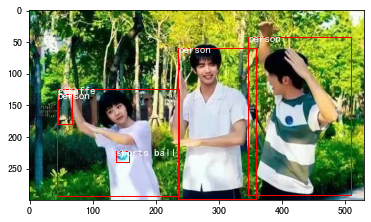

In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 图像读取
img = cv2.imread("image.jpg")
# 实例化
predictor = Predictor()
# 获取结果
boundings = predictor.predict(img)
# 显示图像
plt.imshow(img[:, :, ::-1])
# 获取坐标区域
ax = plt.gca()
# 加载模型：模型训练是在COCO数据集中进行的，
# coco数据集中的类别信息
classes = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 
           'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 
           'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
           'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
           'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 
           'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 
           'skateboard', 'surfboard','tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 
           'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 
           'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 
           'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 
           'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 
           'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
for bounding in boundings:
    # 绘制框
    rect = Rectangle((bounding[0].numpy(), bounding[1].numpy()), bounding[2].numpy(
    ) - bounding[0].numpy(), bounding[3].numpy()-bounding[1].numpy(), color='r', fill=False)
    # 将框显示在图像上
    ax.add_patch(rect)
    # 显示类别信息
    # 获取类别信息的id
    label_id = bounding[5].numpy().astype('int32')
    # 获取类别
    label = classes[label_id]
    # 将标注信息添加在图像上
    ax.text(bounding[0].numpy(), bounding[1].numpy() + 8,
            label, color='w', size=11, backgroundcolor="none")
    # 下一个结果

# 显示图像
plt.show()